# Compare Simulation Models to Experimental Data

Systematic comparison of universalization simulation runs against
participant moral and universalizability judgments.

**Experiments:**
- Logan cross-cultural moral judgments (pooled + per-country)
- Joe moral acceptability judgments (39 stimuli)
- Joe universalizability judgments (39 stimuli)

**Simulations:** various agent models (blind, depth 0/1/2, v1/v2/v3)

**Metrics:** correlation, β, ΔR², ΔBIC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from new_comparison_utils import (
    load_experiments, load_simulations, load_outcome_metrics,
    build_all_design_matrices,
    evaluate_fits, evaluate_fits_multi,
    correlation_matrix, full_correlation_matrix,
    split_half_all,
    plot_grouped_bars, plot_eval_multi, plot_scatter, plot_simple_regression
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load experimental data

In [2]:
datasets = load_experiments(
    joe_moral_agg='joe_moral_agg.csv',
    joe_moral_long='joe_moral_long.csv',
    joe_univ_agg='joe_univ_agg.csv',
    joe_univ_long='joe_univ_long.csv',
    # joe_outcome_agg='joe_outcome_agg.csv',  # uncomment when ready
    #logan_countries=['United States', 'Japan', 'Hungary'],
)

for k, v in datasets.items():
    print(f'  {k:25s} {v}')

  logan_moral               ExperimentalDataset('Logan moral (pooled)', 39 stimuli, ? participants)
  joe_moral                 ExperimentalDataset('Joe moral', 39 stimuli, 39 participants)
  joe_univ                  ExperimentalDataset('Joe univ', 39 stimuli, 43 participants)


## 2. Load simulation runs

In [31]:
# ── Define simulation runs ──
# tag → directory name under data/simulations/

RUNS = {
    # Baselines
    #'joe':          'joe_1_02-06',
    #'random_full':  'full_random_02-06',
    'blind_L0':     'blind_L0_random_02-06',
    'blind_L1':     'blind_l1_random_02-06',
    
    # v1 (random order redrawn every timestep)
    #'depth0':       'depth0_03-16',
    #'depth1':       'depth1_03-16',
    #'depth2':       'depth2_03-16',
    
    # v2 (order drawn once)
    #'depth0_v2':    'v2_d0_03-21',
    #'depth1_v2':    'v2_d1_03-21',
    #'depth2_v2':    'v2_d2_03-21',

    # v3 (order drawn once, everyone sees one step behind rather than at beginning of timestep)
    #'depth0_v3':    'v3_d0_03-24',
    #'depth1_v3':    'v3_d1_03-23',
    #'depth2_v3_1run':    'v3_d2_1run',

    # v4 (fix observation bug in v3 and v2, where agents knew where others we going)
    #'depth0_v4':    'v4_d0',

    # Returning to basics: order drawn once, no depth 
    #'depth0_v1':        'test2_order_drawn_once_2026-04-02_104848', ## FAiled: information leakage
    #'depth0_v2':        'test3_order_once_but_snapshot_timestep_2026-04-02_123334', # Attempt at blind_l0 but with order drawn once
    #'depth0_v3':        'test4_snapshot_2026-04-02_132345', # Attempt at real depth0 --- info leaked
    #'depth0_v3_bis':    'test5_snapshot_nomemoization_2026-04-02_143134', # Real depth0 attempt2 --- test without memoization

    # Laisse beton le snapshot - all plan from start of timestep
    #'depth0_v4': 'depth0_2026-04-02_155550',
    #'depth1_v4': 'depth1_2026-04-02_162801',
    #'depth2_v4': 'depth2_2026-04-02_184604', # failed: agents got stucks (leading to positive universalization scores) 
    #'depth2_v5': 'depth2_fix_2026-04-03_090825',
    #'depth2_v6': 'depth2_more_complex_2026-04-07_122251', # failed: agents got stuck (version where A* done for all routes)

     # 
    'depth0': 'depth0_2026-04-02_155550',
    'depth1': 'depth1_2026-04-02_162801',
    'depth2_v1': 'depth2_fix_2026-04-03_090825', # PROBLEM: less knowledge than depth1, just plans assuming others are two steps ahead
    ##### why is depth2_v1 working so well then? Just lucky?
    'depth2_v2': 'depth2_withk_2026-04-08_144157',
    'depth2_v3': 'real_l1_2026-04-09_150543', # [depth>=2 stats] fallbacks: 4773 / 48054 decisions (9.93%)

    ### Ran wrong script (re-ran old script that didn't coverge for d>1 and didn't have levels)
    #'l0_d0': 'L0_main3_2026-04-11_062738',
    #'l0_d1': 'L1h_main3_2026-04-11_070102',
    #'l0_d2': 'real_L1_main3_2026-04-11_020808',
    #'l0_d3': 'real_L1_d3_2026-04-11_081045',
    #'l1_d1': 'L2_heuristic_2026-04-10_202137',
    #'l1_d2': 'real_L2_2026-04-10_214206',
    #'l2_d1': 'L3_heuristic_2026-04-11_145538',
    # 
}

sims = load_simulations(RUNS, recompute=True)

### WATCH OUT FOR RUNS WHERE STUCK, they can contribute to positive univ score / should probably get excluded from summary (when we "build")?

Processed 28 maps for run_label='blind_L0_random_02-06' and saved to ../data/simulations/blind_L0_random_02-06/processed
Built universalization summary for run_label='blind_L0_random_02-06' over 28 maps and saved to summary_universalization_metrics.csv
  blind_L0              28 maps  mean U_AW=-3.019
Processed 28 maps for run_label='blind_l1_random_02-06' and saved to ../data/simulations/blind_l1_random_02-06/processed
Built universalization summary for run_label='blind_l1_random_02-06' over 28 maps and saved to summary_universalization_metrics.csv
  blind_L1              28 maps  mean U_AW=-1.210
Processed 28 maps for run_label='depth0_2026-04-02_155550' and saved to ../data/simulations/depth0_2026-04-02_155550/processed
Built universalization summary for run_label='depth0_2026-04-02_155550' over 28 maps and saved to summary_universalization_metrics.csv
  depth0                28 maps  mean U_AW=-2.262
Processed 28 maps for run_label='depth1_2026-04-02_162801' and saved to ../data/si

In [32]:
# Load outcome metrics (one-cut scenario effects)
out_df = load_outcome_metrics()

## 3. Build design matrices (all runs × all experiments)

In [33]:
# Build design matrices: dict[exp_key][tag] → DataFrame
dm = {}
for exp_key, exp in datasets.items():
    dm[exp_key] = build_all_design_matrices(sims, out_df, exp)
    n_stim = list(dm[exp_key].values())[0].shape[0] if dm[exp_key] else 0
    print(f'  {exp_key:25s} {len(dm[exp_key])} runs × {n_stim} stimuli')

  logan_moral               7 runs × 39 stimuli
  joe_moral                 7 runs × 39 stimuli
  joe_univ                  7 runs × 39 stimuli


## 4. Correlation table (experiments × runs)

In [36]:
RUN_ORDER = [
    #'joe', 'random_full', 
    'blind_L0', 'blind_L1',
    'depth0', 'depth1', 'depth2_v1', 'depth2_v2','depth2_v3',
    #'l0_d0','l0_d1','l0_d2','l0_d3',
    #'l1_d1','l1_d2','l2_d1',
]


EXP_ORDER = [
    'logan_moral',
    #'logan_united_states',
    #'logan_japan',
    #'logan_hungary',
    'joe_univ',
    'joe_moral',
]

corr, styled = correlation_matrix(
    dm, datasets,
    run_order=RUN_ORDER,
    exp_order=[k for k in EXP_ORDER if k in dm],
    group_separators=[1, 3,6],   # separator after baselines
    save_path='figures/correlation_table.csv',
)
styled

  Saved figures/correlation_table.csv


,blind_L0,blind_L1,depth0,depth1,depth2_v1,depth2_v2,depth2_v3
experiment,,,,,,,
Logan moral (pooled),0.233,0.589,0.278,0.461,0.572,0.583,0.617
Joe univ,0.507,0.836,0.581,0.762,0.855,0.838,0.781
Joe moral,0.204,0.653,0.264,0.561,0.622,0.593,0.653


In [37]:
corr_full, styled_full = full_correlation_matrix(
    dm, datasets,
    run_order=RUN_ORDER,
    exp_order=[k for k in EXP_ORDER if k in dm],
    group_separators=[2, 4, 6,9],  # after DVs | after baselines | after v1
    save_path='figures/full_correlation_matrix.csv',
)
styled_full

  Saved figures/full_correlation_matrix.csv


,Logan moral (pooled),Joe univ,Joe moral,blind_L0,blind_L1,depth0,depth1,depth2_v1,depth2_v2,depth2_v3
Logan moral (pooled),1.000,0.783,0.952,0.233,0.589,0.278,0.461,0.572,0.583,0.617
Joe univ,0.783,1.000,0.805,0.507,0.836,0.581,0.762,0.855,0.838,0.781
Joe moral,0.952,0.805,1.000,0.204,0.653,0.264,0.561,0.622,0.593,0.653
blind_L0,0.233,0.507,0.204,1.000,0.601,0.721,0.493,0.648,0.698,0.453
blind_L1,0.589,0.836,0.653,0.601,1.000,0.679,0.928,0.944,0.909,0.868
depth0,0.278,0.581,0.264,0.721,0.679,1.000,0.595,0.691,0.723,0.559
depth1,0.461,0.762,0.561,0.493,0.928,0.595,1.000,0.859,0.778,0.742
depth2_v1,0.572,0.855,0.622,0.648,0.944,0.691,0.859,1.000,0.906,0.793
depth2_v2,0.583,0.838,0.593,0.698,0.909,0.723,0.778,0.906,1.000,0.823
depth2_v3,0.617,0.781,0.653,0.453,0.868,0.559,0.742,0.793,0.823,1.000


## 5. Evaluate fits (ΔR², β, p) per experiment

In [38]:
# Evaluate against Logan pooled
eval_logan = evaluate_fits(
    dm['logan_moral'], datasets['logan_moral'],
    save_path='figures/eval_logan_pooled.csv',
)
eval_logan[['tag', 'r_U_AW', 'delta_R2', 'beta_U_AW', 'p_U_AW']].round(4)

  Saved figures/eval_logan_pooled.csv


,tag,r_U_AW,delta_R2,beta_U_AW,p_U_AW
0,depth2_v1,0.5723,0.0903,0.1297,0.0024
1,blind_L1,0.5890,0.0792,0.1100,0.0048
2,depth2_v3,0.6166,0.0613,0.0555,0.0144
3,depth2_v2,0.5829,0.0447,0.0878,0.0391
4,depth1,0.4610,0.0444,0.0621,0.0399
5,depth0,0.2783,0.0117,0.0269,0.3023
6,blind_L0,0.2333,0.0000,0.0012,0.9515


In [39]:
# Evaluate against Joe universalizability
eval_joe_univ = evaluate_fits(
    dm['joe_univ'], datasets['joe_univ'],
    save_path='figures/eval_joe_univ.csv',
)
eval_joe_univ[['tag', 'r_U_AW', 'delta_R2', 'beta_U_AW', 'p_U_AW']].round(4)

  Saved figures/eval_joe_univ.csv


,tag,r_U_AW,delta_R2,beta_U_AW,p_U_AW
0,depth2_v1,0.8554,0.4264,8.1941,0.0000
1,blind_L1,0.8365,0.3806,7.0112,0.0000
2,depth2_v2,0.8376,0.3434,7.0746,0.0000
3,depth1,0.7622,0.3296,4.9229,0.0000
4,depth2_v3,0.7812,0.2663,3.3656,0.0000
5,depth0,0.5815,0.1800,3.0615,0.0005
6,blind_L0,0.5069,0.1029,1.7746,0.0119


In [40]:
# Evaluate against Joe moral
eval_joe_moral = evaluate_fits(
    dm['joe_moral'], datasets['joe_moral'],
    save_path='figures/eval_joe_moral.csv',
)
eval_joe_moral[['tag', 'r_U_AW', 'delta_R2', 'beta_U_AW', 'p_U_AW']].round(4)

  Saved figures/eval_joe_moral.csv


,tag,r_U_AW,delta_R2,beta_U_AW,p_U_AW
0,depth2_v1,0.6224,0.1642,5.7395,0.0001
1,blind_L1,0.6528,0.1545,5.0420,0.0002
2,depth2_v3,0.6527,0.1228,2.5794,0.0011
3,depth1,0.5615,0.1224,3.3852,0.0011
4,depth2_v2,0.5933,0.0798,3.8495,0.0105
5,depth0,0.2637,0.0252,1.2924,0.1645
6,blind_L0,0.2041,0.0013,0.2262,0.7542


## 6. Plots

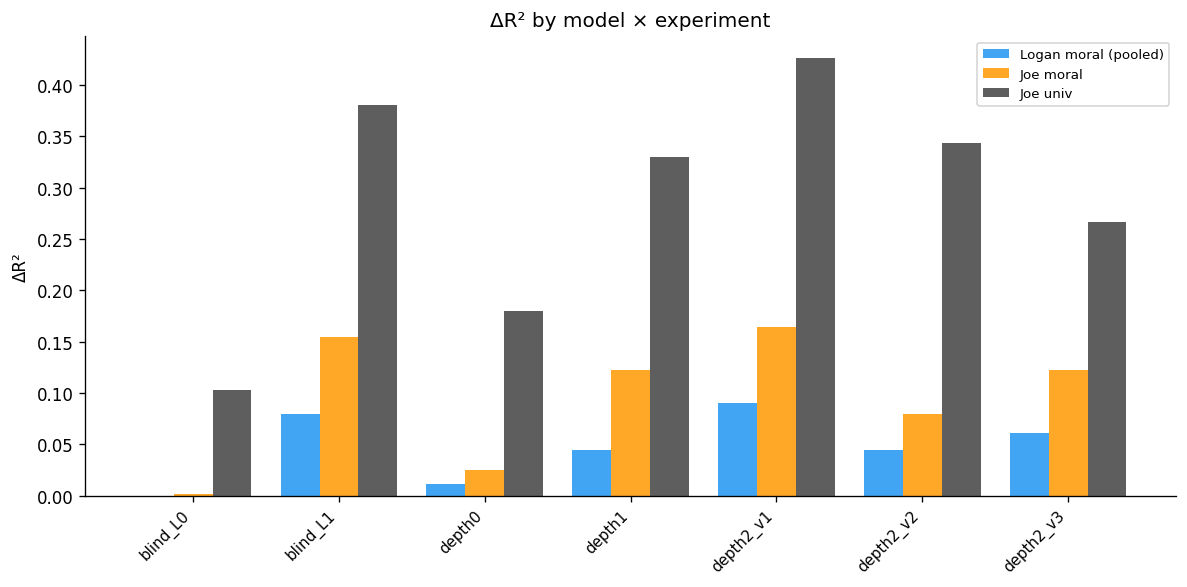

In [41]:
# Multi-experiment comparison

import matplotlib.pyplot as plt

eval_all = evaluate_fits_multi(dm, datasets)

keep_exps = ['Logan moral (pooled)', 'Joe moral', 'Joe univ']
eval_filtered = eval_all[eval_all['experiment'].isin(keep_exps)]


plot_eval_multi(eval_filtered, metric='delta_R2', run_order=RUN_ORDER,
                save_path='figures/delta_r2_baseline_and_new.png');


In [143]:
reliability = split_half_all(datasets)
reliability

,name,n_participants,n_stimuli,r_half,ci_lo,ci_hi,spearman_brown,noise_ceiling
0,Joe moral,39,39,0.9680,0.9431,0.9825,0.9837,0.9918
1,Joe univ,43,39,0.9615,0.9321,0.9800,0.9804,0.9901


In [126]:
# SUBSET STUFF DEPTH 2 APRIL 2


depth2_v5 covers 12 stimuli from 9 maps


,blind_L0,blind_L1,depth0_v4,depth1_v4,depth2_v5
experiment,,,,,
Logan moral (pooled),0.900,0.779,0.715,0.733,0.765
Joe univ,0.945,0.905,0.880,0.879,0.949
Joe moral,0.882,0.810,0.765,0.773,0.807


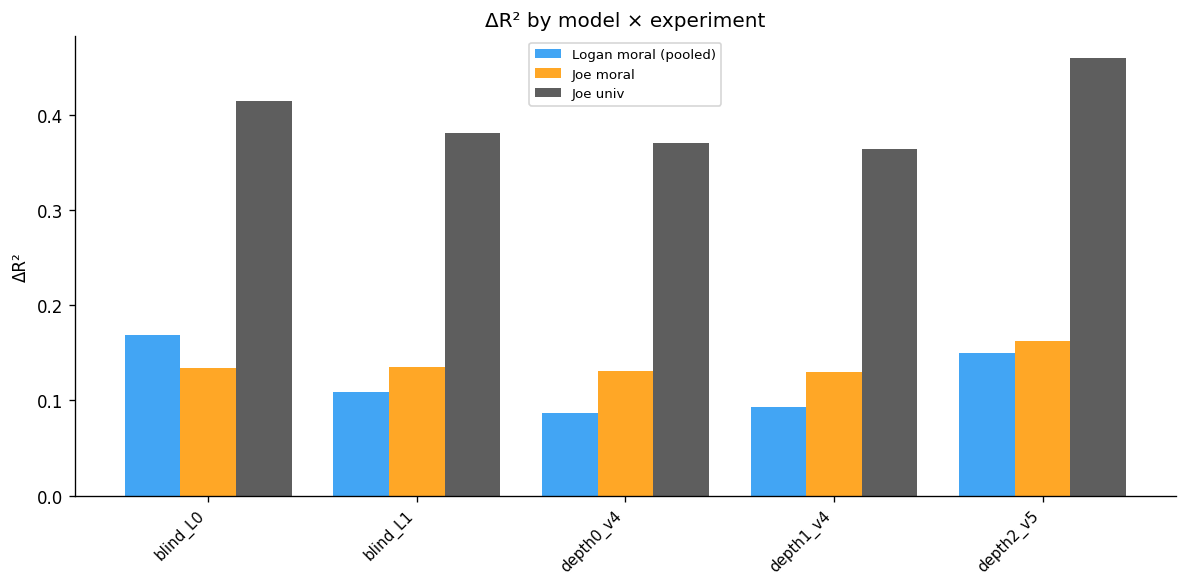

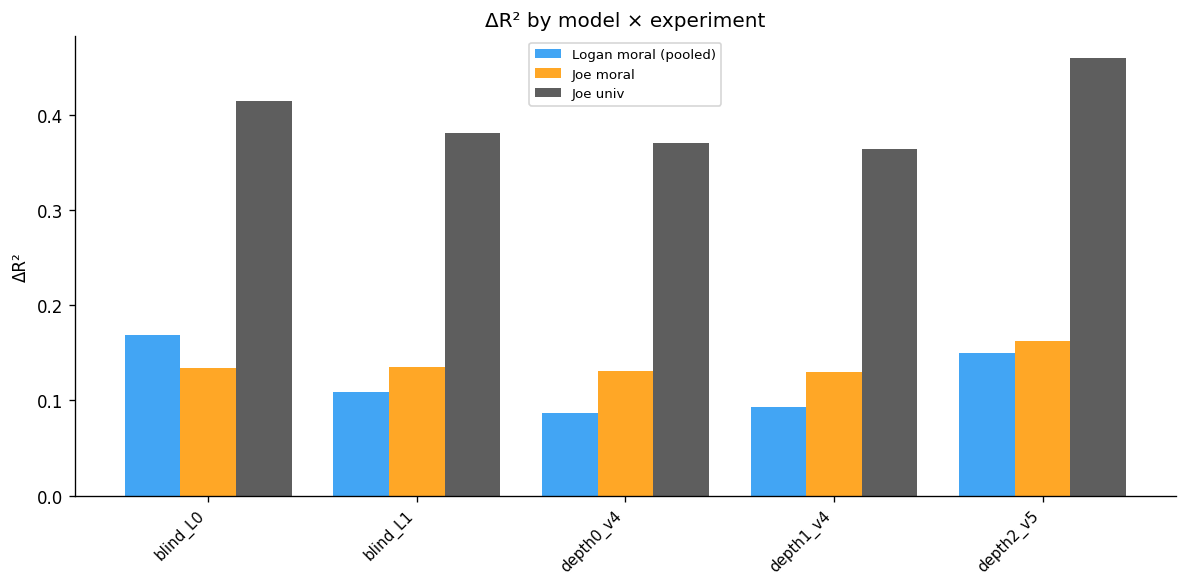

In [129]:
finished_maps = [
    '9esque', 'maybe_6', 'new_maybe_4', 'no_line_1', 'no_line_2',
    'no_line_A', 'no_line_B', 'no_line_D', 'yes_line_D'
]

d2_stims = set(dm['joe_univ']['depth2_v5'][
    dm['joe_univ']['depth2_v5']['map'].isin(finished_maps)
]['stimulus'].unique())
print(f"depth2_v5 covers {len(d2_stims)} stimuli from {len(finished_maps)} maps")

# Filter ALL runs to just those stimuli
dm_sub = {}
for exp_key in dm:
    dm_sub[exp_key] = {}
    for tag in dm[exp_key]:
        df = dm[exp_key][tag]
        filtered = df[df['stimulus'].isin(d2_stims)]
        if len(filtered) > 0:
            dm_sub[exp_key][tag] = filtered

# Now run your usual analysis on the subset
RUN_ORDER = ['blind_L0', 'blind_L1', 'depth0_v4', 'depth1_v4', 'depth2_v5']
EXP_ORDER = [k for k in ['logan_moral', 'joe_univ', 'joe_moral'] if k in dm_sub]

corr_sub, styled_sub = correlation_matrix(
    dm_sub, datasets,
    run_order=RUN_ORDER,
    exp_order=EXP_ORDER,
)
display(styled_sub)

eval_sub = evaluate_fits_multi(dm_sub, datasets)
keep_exps = ['Logan moral (pooled)', 'Joe moral', 'Joe univ']
eval_sub_filtered = eval_sub[eval_sub['experiment'].isin(keep_exps)]
plot_eval_multi(eval_sub_filtered, metric='delta_R2',
                run_order=RUN_ORDER,
                save_path='figures/delta_r2_subset_d2v5.png')

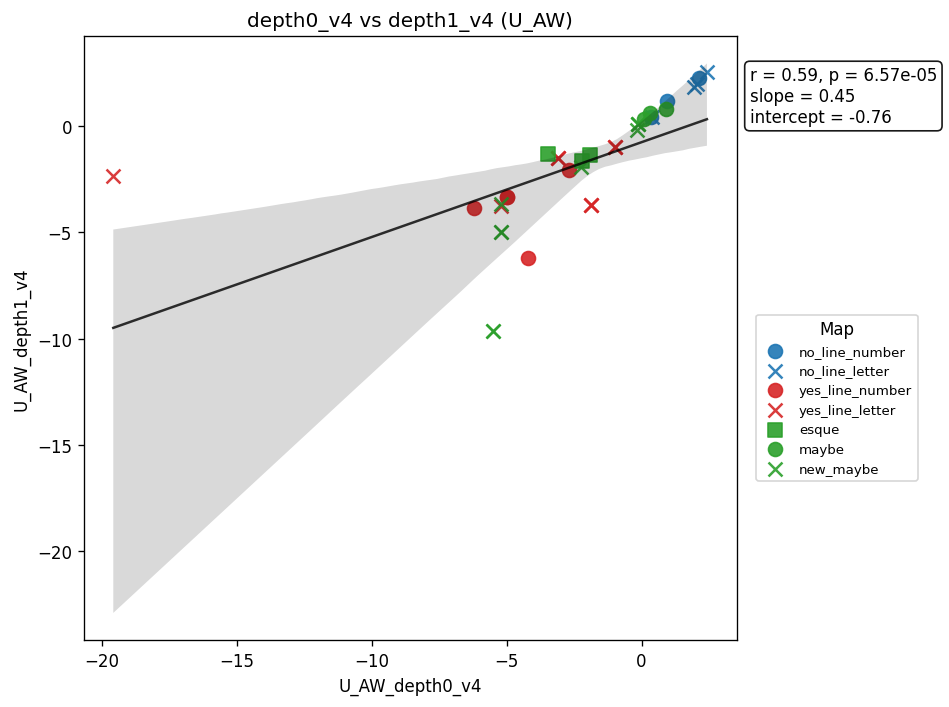

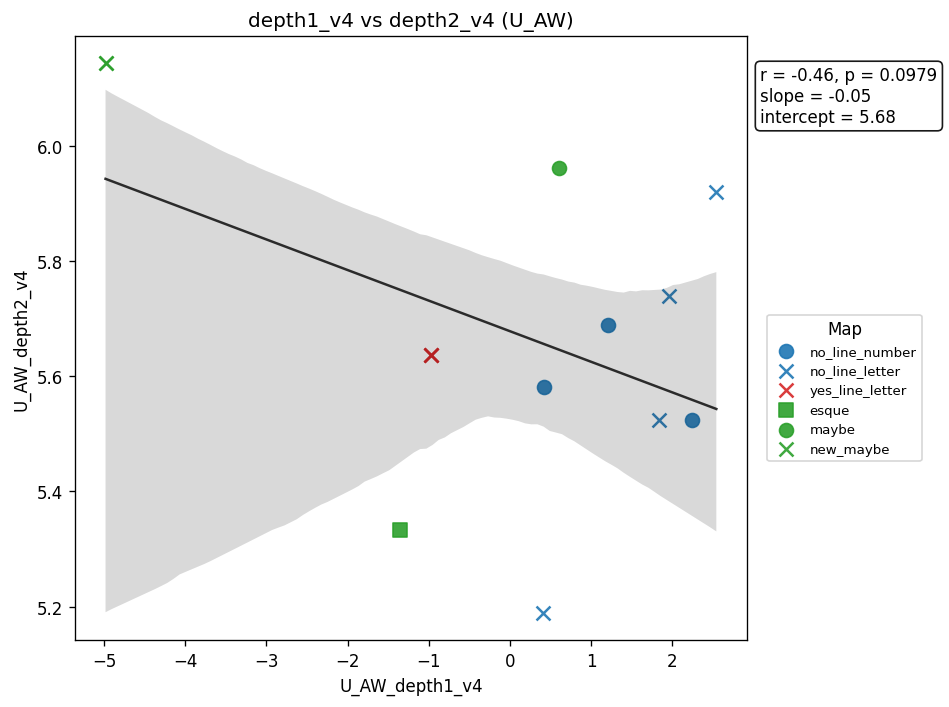

,blind_L0,blind_L1,depth0_v4,depth1_v4,depth2_v4
experiment,,,,,
Logan moral (pooled),0.233,0.589,0.278,0.461,-0.283
Joe univ,0.507,0.836,0.581,0.762,-0.349
Joe moral,0.204,0.653,0.264,0.561,-0.352


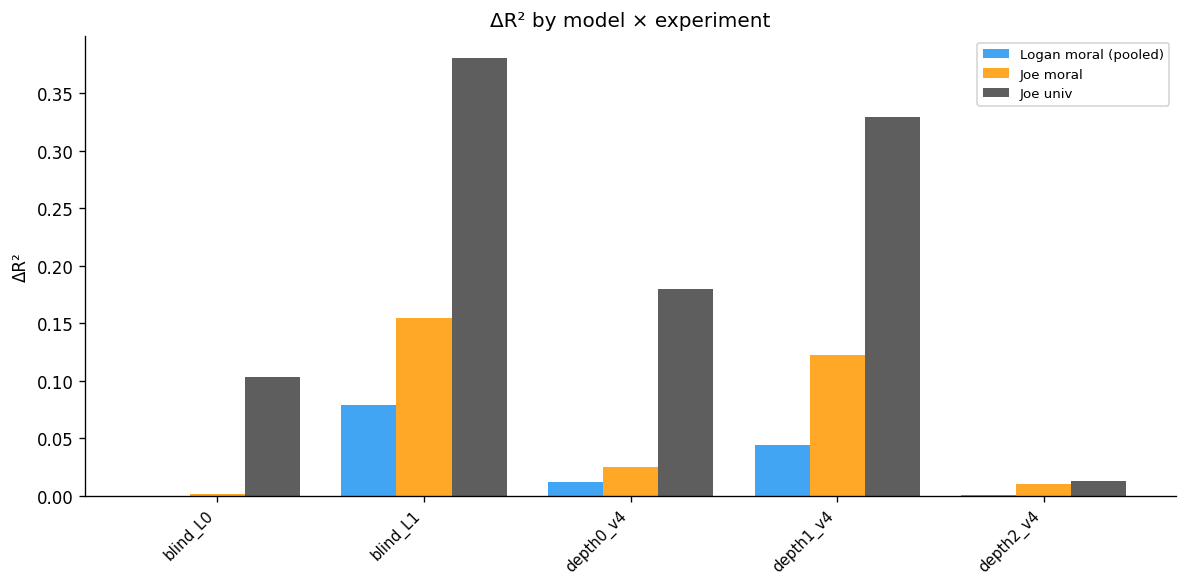

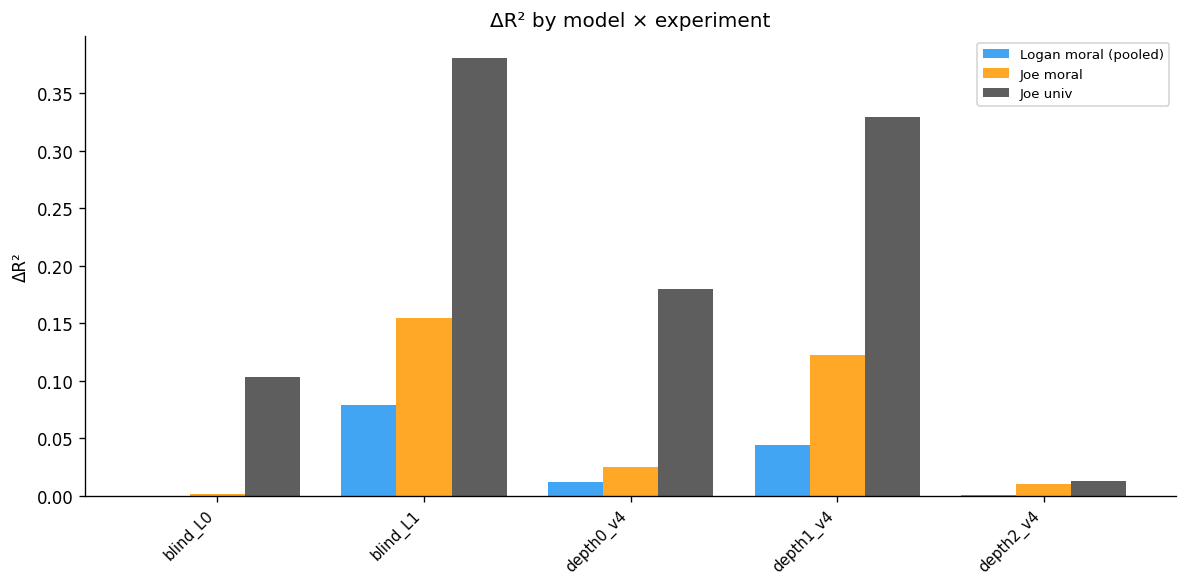

In [114]:
# =============================================================================
# CELL 1: depth1_v4 vs depth0_v4 scatter
# =============================================================================

a = dm['logan_moral']['depth0_v4'][['stimulus', 'map', 'univ_aggregate_welfare']].rename(
    columns={'univ_aggregate_welfare': 'U_AW_depth0_v4'})
b = dm['logan_moral']['depth1_v4'][['stimulus', 'univ_aggregate_welfare']].rename(
    columns={'univ_aggregate_welfare': 'U_AW_depth1_v4'})
merged = a.merge(b, on='stimulus')

plot_simple_regression(merged, x_col='U_AW_depth0_v4', y_col='U_AW_depth1_v4',
                       title='depth0_v4 vs depth1_v4 (U_AW)',
                       save_path='figures/depth0_v4_vs_depth1_v4')

# =============================================================================
# CELL 2: depth2_v4 vs depth1_v4 scatter
# =============================================================================

a = dm['logan_moral']['depth1_v4'][['stimulus', 'map', 'univ_aggregate_welfare']].rename(
    columns={'univ_aggregate_welfare': 'U_AW_depth1_v4'})
b = dm['logan_moral']['depth2_v4'][['stimulus', 'univ_aggregate_welfare']].rename(
    columns={'univ_aggregate_welfare': 'U_AW_depth2_v4'})
merged = a.merge(b, on='stimulus')

plot_simple_regression(merged, x_col='U_AW_depth1_v4', y_col='U_AW_depth2_v4',
                       title='depth1_v4 vs depth2_v4 (U_AW)',
                       save_path='figures/depth1_v4_vs_depth2_v4')

# =============================================================================
# CELL 3: Correlation table + ΔR² on v4 runs
# =============================================================================

RUN_ORDER_V4 = ['blind_L0', 'blind_L1', 'depth0_v4', 'depth1_v4', 'depth2_v4']
EXP_ORDER = [k for k in ['logan_moral', 'joe_univ', 'joe_moral'] if k in dm]

corr_v4, styled_v4 = correlation_matrix(
    dm, datasets,
    run_order=RUN_ORDER_V4,
    exp_order=EXP_ORDER,
)
display(styled_v4)
corr_v4.to_csv('figures/correlation_table_v4.csv')

eval_v4 = evaluate_fits_multi(dm, datasets)
keep_exps = ['Logan moral (pooled)', 'Joe moral', 'Joe univ']
eval_v4_filtered = eval_v4[eval_v4['experiment'].isin(keep_exps)]

plot_eval_multi(eval_v4_filtered, metric='delta_R2',
                run_order=RUN_ORDER_V4,
                save_path='figures/delta_r2_v4.png')

## 8. Per-map scatter plot

In [93]:
# UNIV

In [79]:
# testing new depth 2 vs depth 1

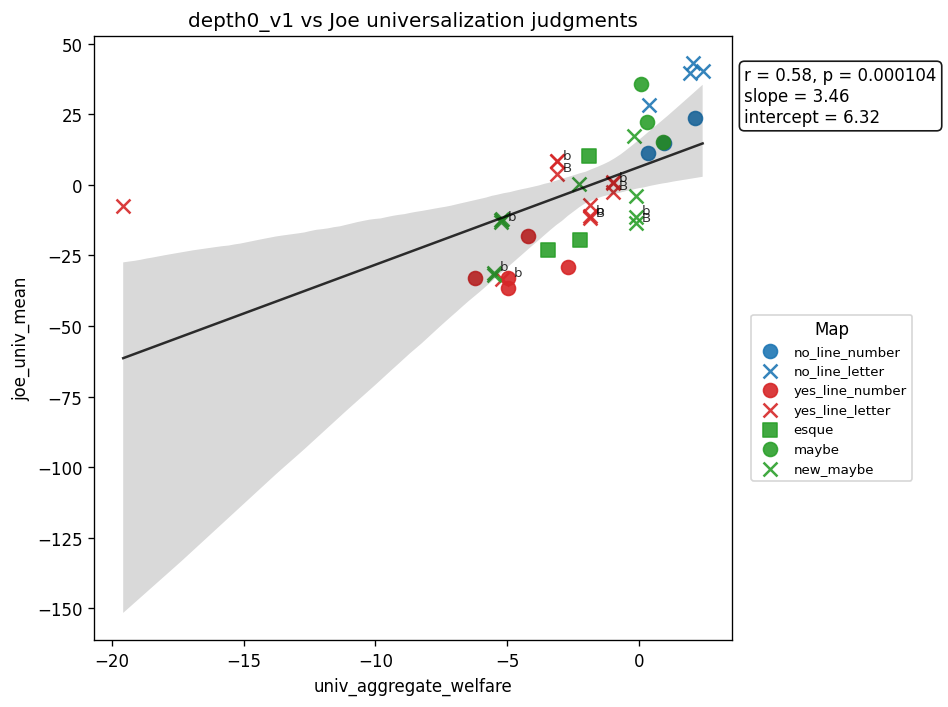

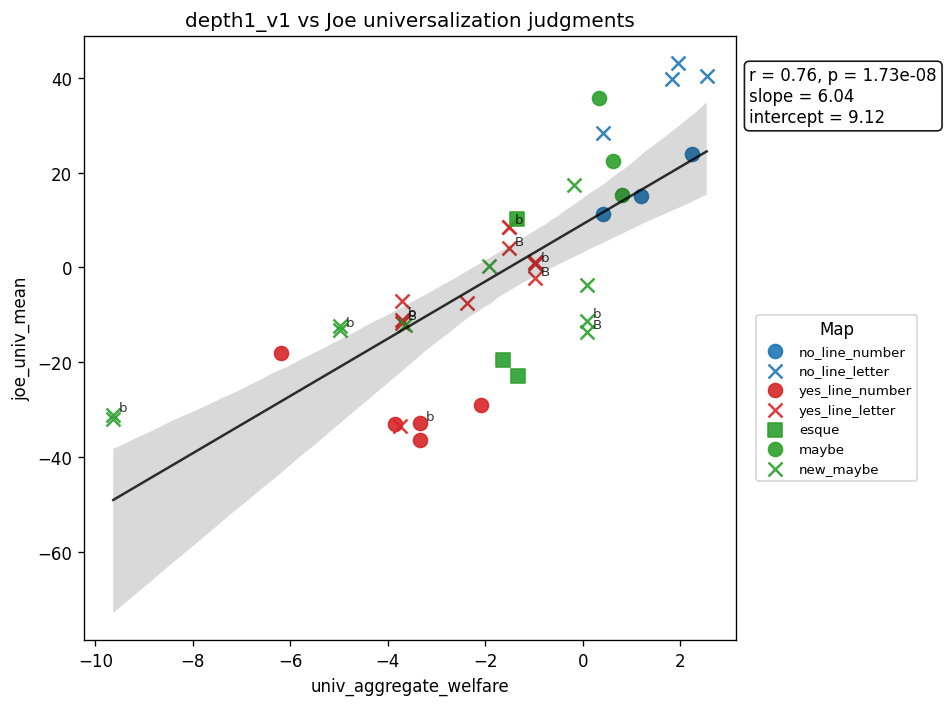

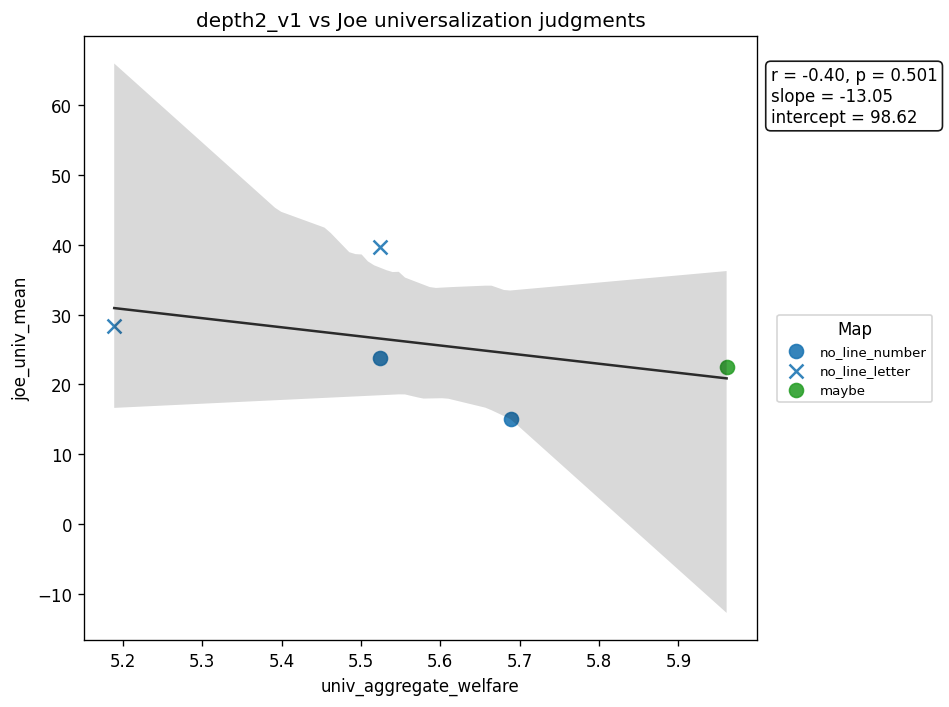

(<Figure size 960x720 with 1 Axes>,
 <Axes: title={'center': 'depth2_v1 vs Joe universalization judgments'}, xlabel='univ_aggregate_welfare', ylabel='joe_univ_mean'>)

In [62]:
### V1
plot_simple_regression(dm['joe_univ']['depth0_v4'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_univ_mean',
                       title='depth0_v1 vs Joe universalization judgments',
                       display_condition=True,
                      save_path="figures/univ_vs_d0_v1")

plot_simple_regression(dm['joe_univ']['depth1_v4'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_univ_mean',
                       title='depth1_v1 vs Joe universalization judgments',
                       display_condition=True,
                        save_path="figures/univ_vs_d1_v1")

plot_simple_regression(dm['joe_univ']['depth2_v4'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_univ_mean',
                       title='depth2_v1 vs Joe universalization judgments',
                       display_condition=True,
                            save_path="figures/univ_vs_d2_v1")


In [ ]:
# MORAL

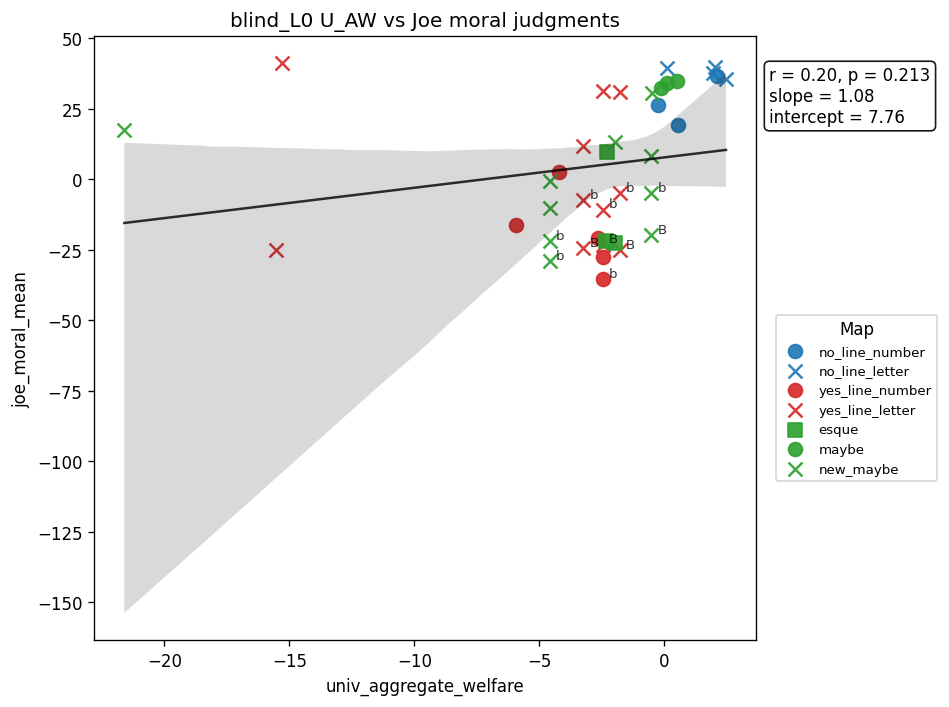

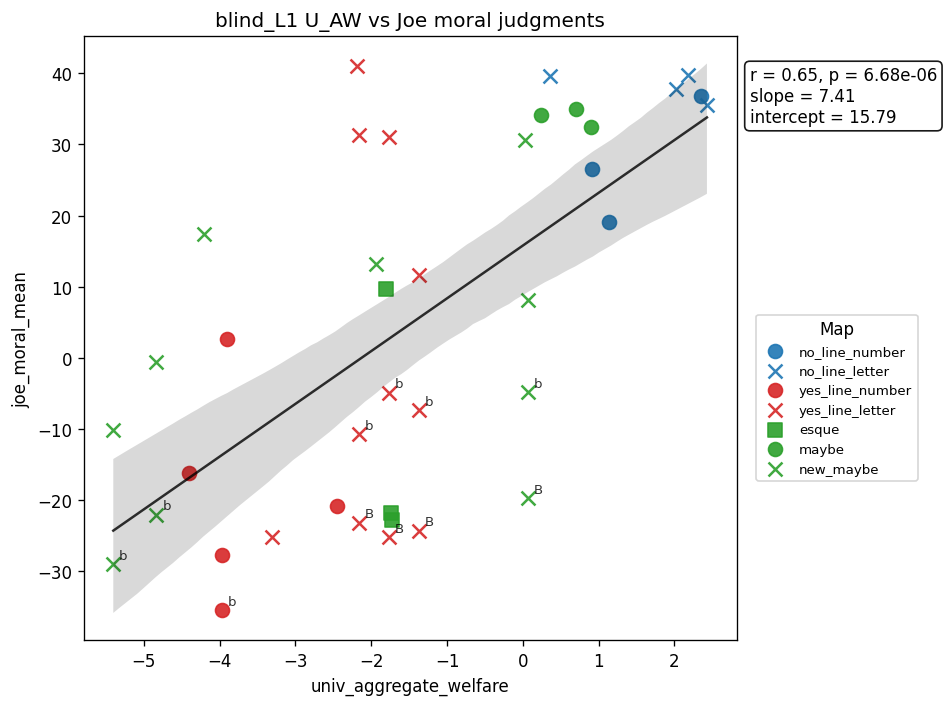

(<Figure size 960x720 with 1 Axes>,
 <Axes: title={'center': 'blind_L1 U_AW vs Joe moral judgments'}, xlabel='univ_aggregate_welfare', ylabel='joe_moral_mean'>)

In [31]:
### Baslines
plot_simple_regression(dm['joe_moral']['blind_L0'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='blind_L0 U_AW vs Joe moral judgments',
                       display_condition=True,
                        save_path="figures/joe_vs_blind_L0")

plot_simple_regression(dm['joe_moral']['blind_L1'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='blind_L1 U_AW vs Joe moral judgments',
                       display_condition=True,
                        save_path="figures/joe_vs_blind_L1")


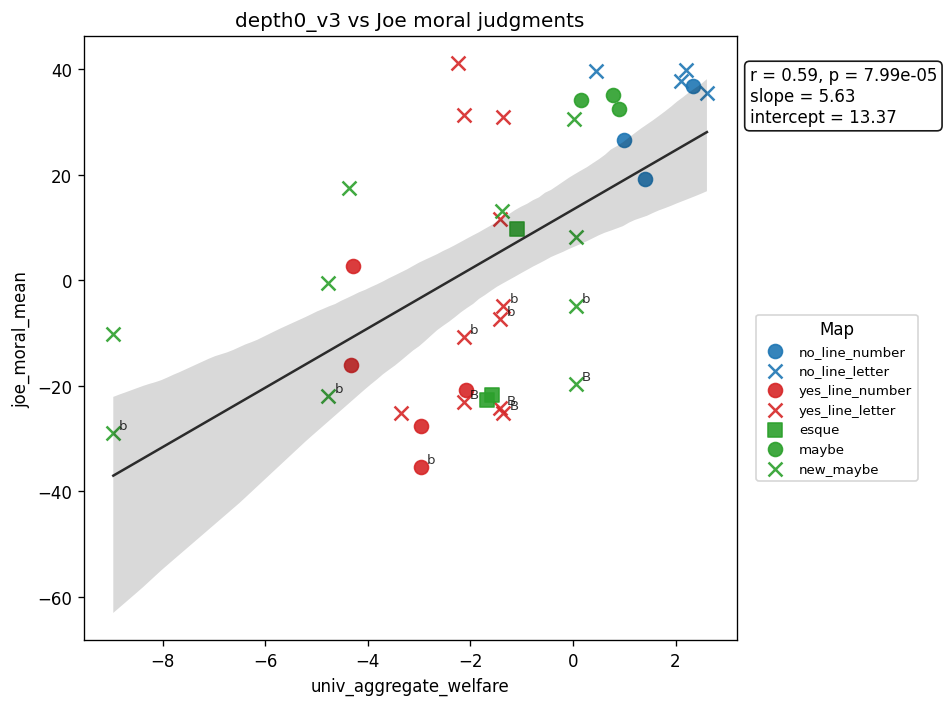

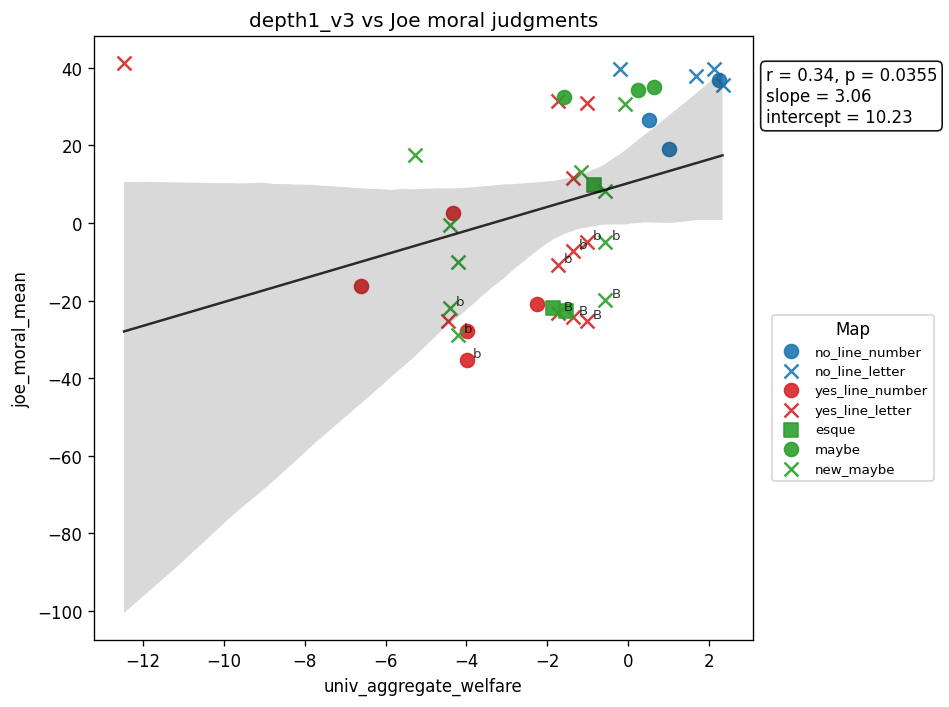

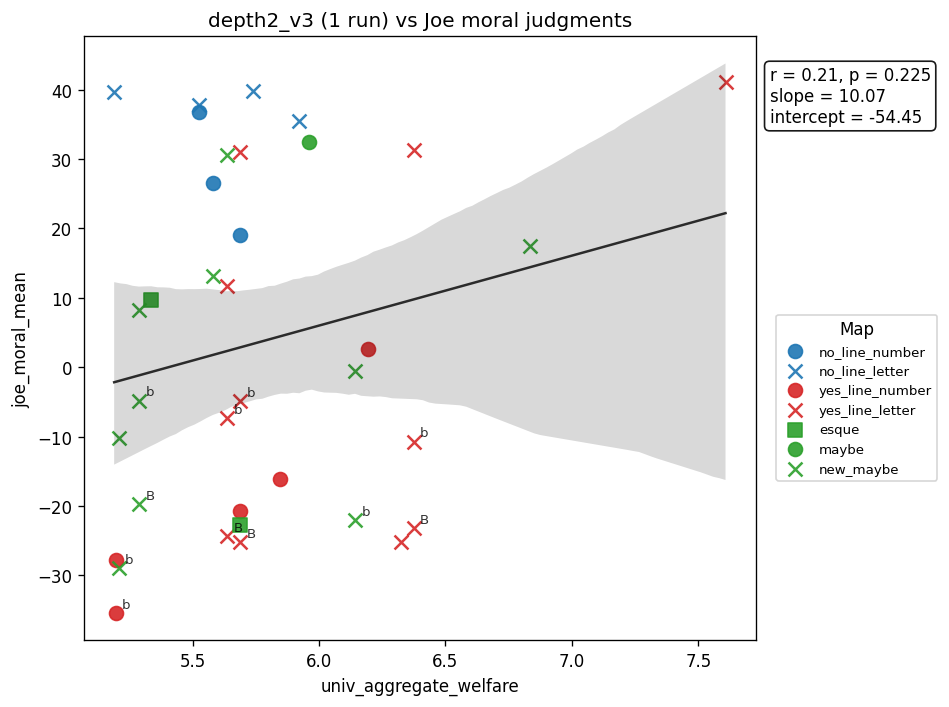

(<Figure size 960x720 with 1 Axes>,
 <Axes: title={'center': 'depth2_v3 (1 run) vs Joe moral judgments'}, xlabel='univ_aggregate_welfare', ylabel='joe_moral_mean'>)

In [32]:
### V3
plot_simple_regression(dm['joe_moral']['depth0_v3'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth0_v3 vs Joe moral judgments',
                       display_condition=True,
                      save_path="figures/joe_vs_d0_v3")

plot_simple_regression(dm['joe_moral']['depth1_v3'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth1_v3 vs Joe moral judgments',
                       display_condition=True,
                        save_path="figures/joe_vs_d1_v3")

plot_simple_regression(dm['joe_moral']['depth2_v3_1run'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth2_v3 (1 run) vs Joe moral judgments',
                       display_condition=True,
                            save_path="figures/joe_vs_d2_v3_1run")


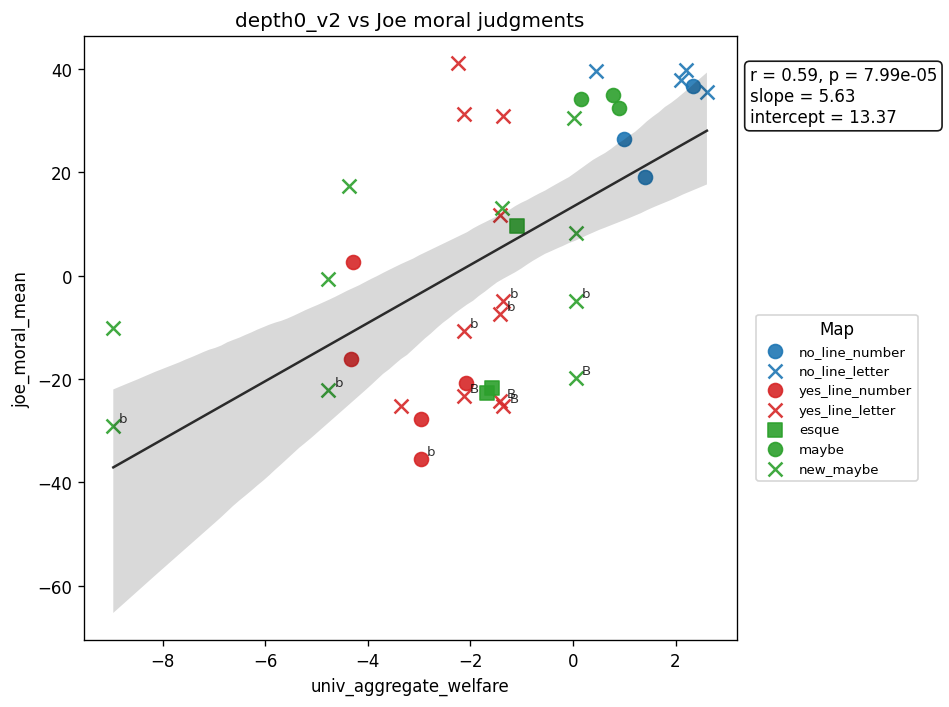

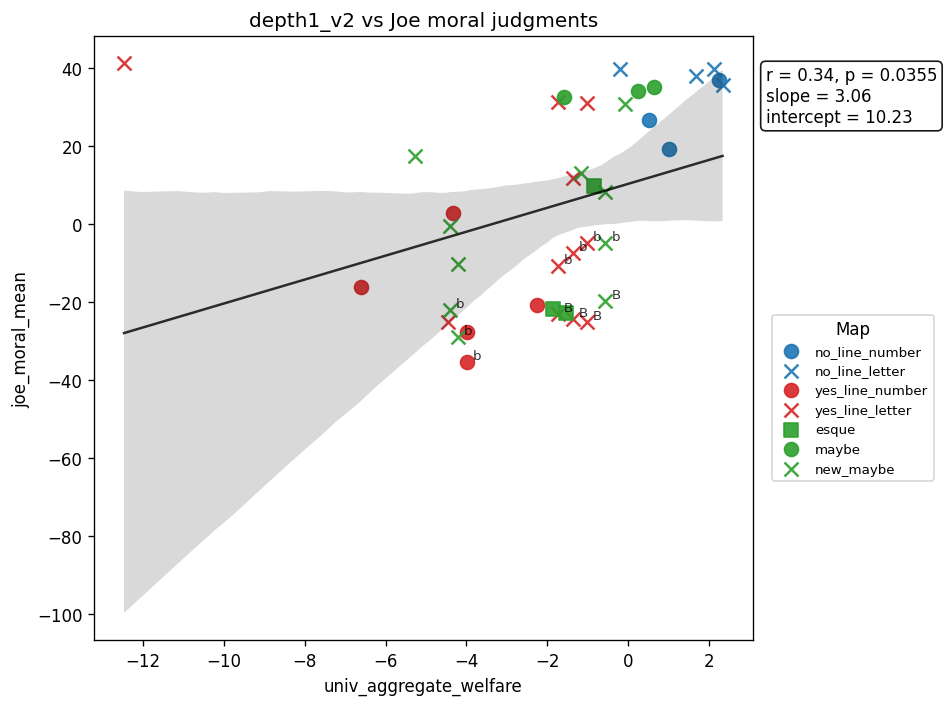

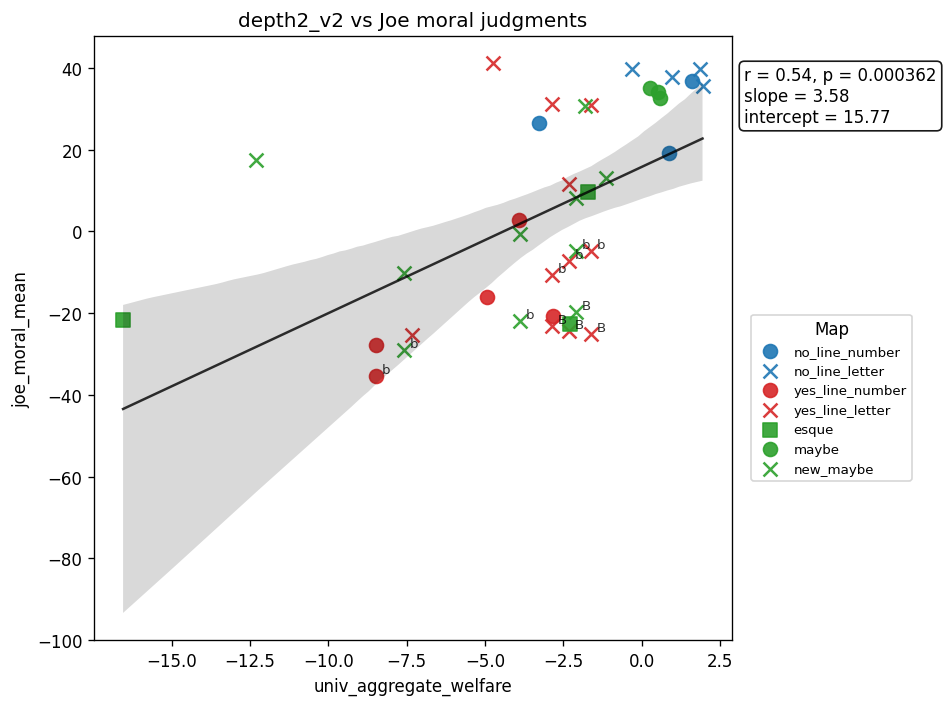

(<Figure size 960x720 with 1 Axes>,
 <Axes: title={'center': 'depth2_v2 vs Joe moral judgments'}, xlabel='univ_aggregate_welfare', ylabel='joe_moral_mean'>)

In [34]:
### V2
plot_simple_regression(dm['joe_moral']['depth0_v2'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth0_v2 vs Joe moral judgments',
                       display_condition=True,
                      save_path="figures/joe_vs_d0_v2")

plot_simple_regression(dm['joe_moral']['depth1_v2'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth1_v2 vs Joe moral judgments',
                       display_condition=True,
                        save_path="figures/joe_vs_d1_v2")

plot_simple_regression(dm['joe_moral']['depth2_v2'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth2_v2 vs Joe moral judgments',
                       display_condition=True,
                            save_path="figures/joe_vs_d2_v2")


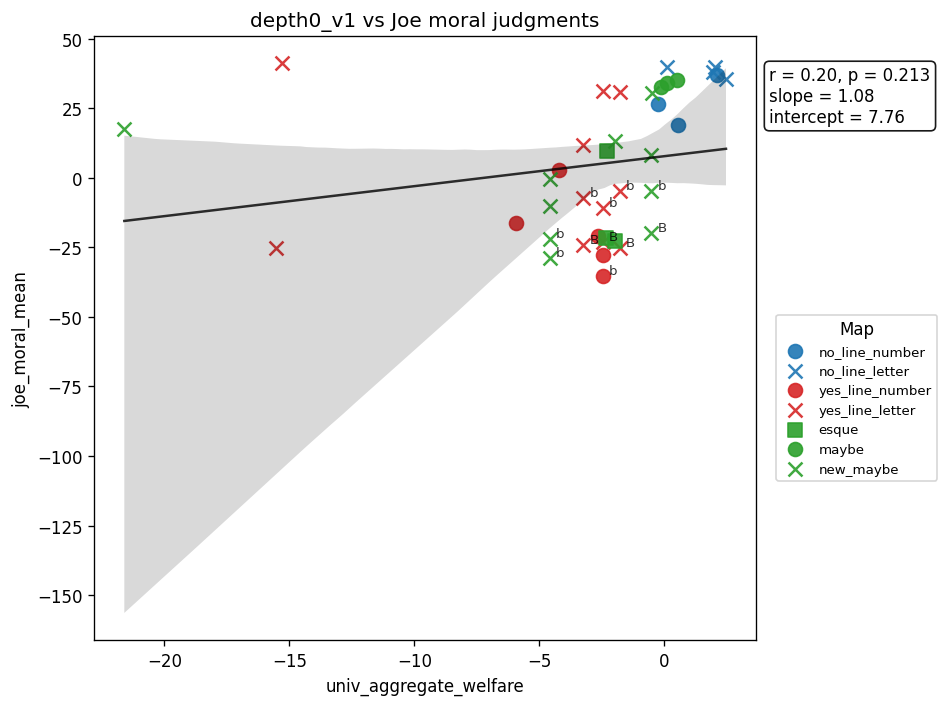

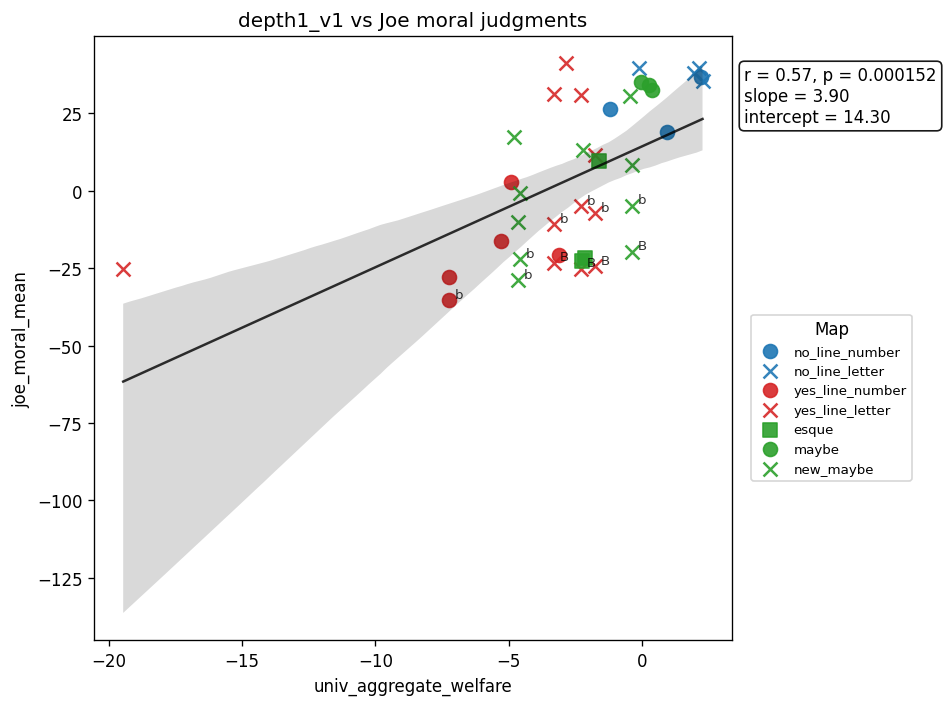

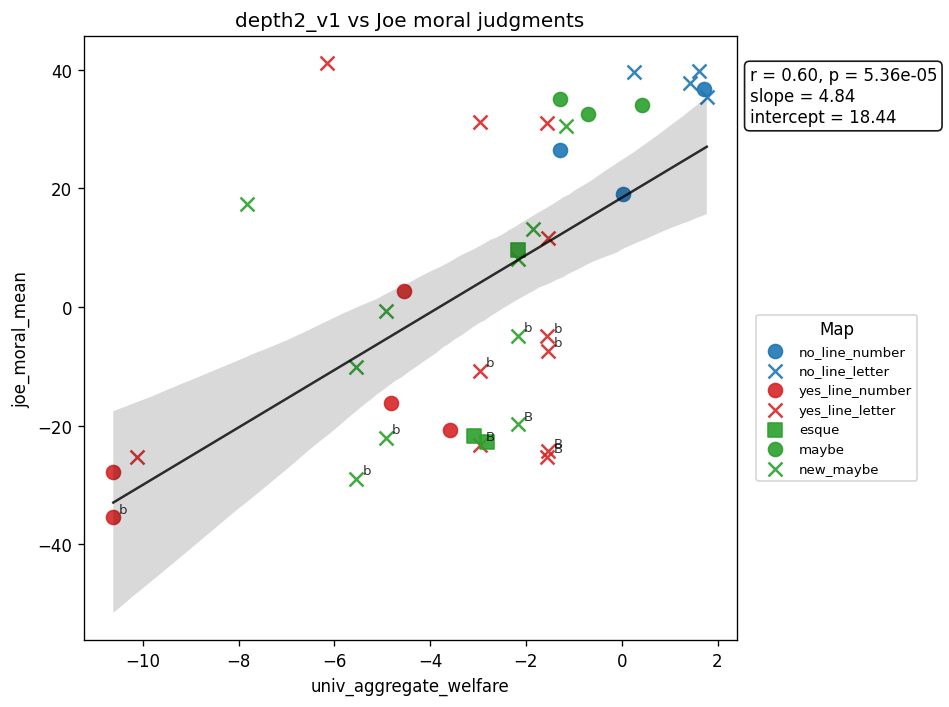

(<Figure size 960x720 with 1 Axes>,
 <Axes: title={'center': 'depth2_v1 vs Joe moral judgments'}, xlabel='univ_aggregate_welfare', ylabel='joe_moral_mean'>)

In [35]:
### V1
plot_simple_regression(dm['joe_moral']['depth0'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth0_v1 vs Joe moral judgments',
                       display_condition=True,
                      save_path="figures/joe_vs_d0_v1")

plot_simple_regression(dm['joe_moral']['depth1'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth1_v1 vs Joe moral judgments',
                       display_condition=True,
                        save_path="figures/joe_vs_d1_v1")

plot_simple_regression(dm['joe_moral']['depth2'],
                       x_col='univ_aggregate_welfare',
                       y_col='joe_moral_mean',
                       title='depth2_v1 vs Joe moral judgments',
                       display_condition=True,
                            save_path="figures/joe_vs_d2_v1")


In [81]:
a = dm['logan_moral']['depth0_v4'][['stimulus', 'map', 'univ_aggregate_welfare']].rename(columns={'univ_aggregate_welfare': 'U_AW_blind_L1'})
b = dm['logan_moral']['depth1_v4'][['stimulus', 'univ_aggregate_welfare']].rename(columns={'univ_aggregate_welfare': 'U_AW_depth0_v2'})
merged = a.merge(b, on='stimulus')
 
plot_simple_regression(merged, x_col='U_AW_depth0_v4', y_col='U_AW_depth1_v4',
                       title='depth0_v4 vs depth1_v4', save_path="depth1_vs_0")

KeyError: ['U_AW_depth0_v4', 'U_AW_depth1_v4']

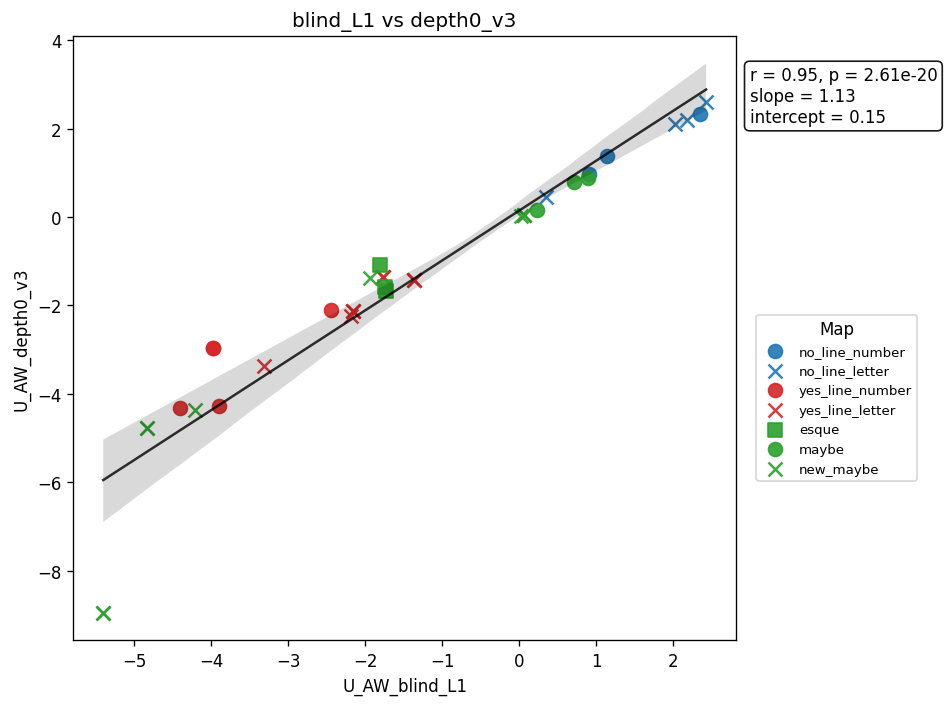

(<Figure size 960x720 with 1 Axes>,
 <Axes: title={'center': 'blind_L1 vs depth0_v3'}, xlabel='U_AW_blind_L1', ylabel='U_AW_depth0_v3'>)

In [29]:
a = dm['logan_moral']['blind_L1'][['stimulus', 'map', 'univ_aggregate_welfare']].rename(columns={'univ_aggregate_welfare': 'U_AW_blind_L1'})
b = dm['logan_moral']['depth0_v3'][['stimulus', 'univ_aggregate_welfare']].rename(columns={'univ_aggregate_welfare': 'U_AW_depth0_v3'})
merged = a.merge(b, on='stimulus')

plot_simple_regression(merged, x_col='U_AW_blind_L1', y_col='U_AW_depth0_v3',
                       title='blind_L1 vs depth0_v3', save_path="blind_L1_vs_depth0_v3")

In [17]:
pairs = [
    ("blind_L0", "depth0_v3"),      
    ("depth0_v3", "depth1_v3"),      
    ("depth0_v3", "depth2_v3_1run"),   
    ("depth1_v3", "depth2_v3_1run"),        
]

for tx, ty in pairs:
    if tx in univ_summaries and ty in univ_summaries:
        fig = scatter_two_models(univ_summaries, tx, ty)
        fig.savefig(f"figures/{tx}_vs_{ty}_scatter.png", dpi=150, bbox_inches="tight")
        plt.show()

NameError: name 'univ_summaries' is not defined